# Setup

In [1]:
import torch
import math

import matplotlib.pyplot as plt
from torch import nn
from functools import partial

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
torch.manual_seed(7)

print("device:", device)

device: cuda


# Drifting

In [2]:
def drifting_loss(gen: torch.Tensor, pos: torch.Tensor, drift_fn):
    with torch.no_grad():
        V = drift_fn(gen, pos, gen)
        target = (gen + V).detach()
    return ((gen - target) ** 2).mean()

def compute_V(X, X_pos, X_neg, *, temp=0.5, mode="gradient",
              ignore_self_neg=True, max_step=None, min_dist=1e-2, eps=1e-8):
    '''Laplace kernel  k(x, y) = exp(-d / temp),  d = ||x - y||.
    Drift  V = (pull toward X_pos) - (push from X_neg):

      base      :  V = E[ k(x,y) (y - x) ] / E[ k(x,y) ]
      gradient  :  V = E[ grad_x k(x,y) ]  / E[ k(x,y) ],
                   with  grad_x k = k(x,y) (y - x) / (temp d)
    '''
    dist_pos = torch.cdist(X, X_pos)
    dist_neg = torch.cdist(X, X_neg)

    k_pos = torch.exp(-dist_pos / temp)
    k_neg = torch.exp(-dist_neg / temp)

    if ignore_self_neg and X.shape[0] == X_neg.shape[0]:   # don't repel a point from itself
        eye = torch.eye(X.shape[0], device=X.device, dtype=torch.bool)
        k_neg = k_neg.masked_fill(eye, 0.0)

    diff_pos = X_pos.unsqueeze(0) - X.unsqueeze(1)         # (y - x), [Nx, Npos, D]
    diff_neg = X_neg.unsqueeze(0) - X.unsqueeze(1)         # (y - x), [Nx, Nneg, D]

    grad_temp = 1
    if mode == "gradient":
        # V = E[grad_x k] / E[k] -> grad_x k = k (y - x) / (temp d)
        grad_temp = temp

    V_pos = (k_pos.unsqueeze(-1) * diff_pos
                / (grad_temp * dist_pos.clamp_min(min_dist)).unsqueeze(-1)).sum(1)
    V_neg = (k_neg.unsqueeze(-1) * diff_neg
                / (grad_temp * dist_neg.clamp_min(min_dist)).unsqueeze(-1)).sum(1)

    V = V_pos - V_neg

    if max_step is not None:
        n = V.norm(dim=-1, keepdim=True)
        V = V * (max_step / n.clamp_min(max_step))
    return V

# Toy 1 — semi-circle: the other half comes for free

Train a generator on the **upper** half of a circle only. The lower half is never in
the training data. It appears anyway, because the architecture cannot represent an
asymmetric output distribution.

**Why.** An O(2)-equivariant map $f:\mathbb{R}^2\to\mathbb{R}^2$ satisfies
$f(Qz) = Qf(z)$ for every orthogonal $Q$. Take $Q$ to be the reflection that fixes
$z$: then $f(z) = Qf(z)$, so $f(z)$ must lie on the ray through $z$. The only such
maps are

$$f(z) \;=\; \rho(\lVert z\rVert)\,\frac{z}{\lVert z\rVert}$$

with $\rho$ a scalar function of the radius alone. The noise is an isotropic
Gaussian, which is O(2)-invariant, so the generated distribution is O(2)-invariant
too — exactly rotationally symmetric, by construction.

The drift field is built from a Laplace kernel on pairwise distances, which is also
O(2)-invariant. Minimizing a kernel discrepancy over an invariant model class lands
on the group-symmetrization of the target, and the symmetrization of an upper arc is
the full ring. So the training signal is consistent with what the architecture can
express. Concretely: every angle shares the one radial profile $\rho$, so the
upper-arc data teaches $\rho(r)\to 1$ and every angle inherits it.

**Be precise about the claim.** The model *learns* the radial profile. The angular
completion is *architectural*, not inferred from data. A plain MLP trained on the
same data is included as a control, and covers only the upper arc.

### Setup

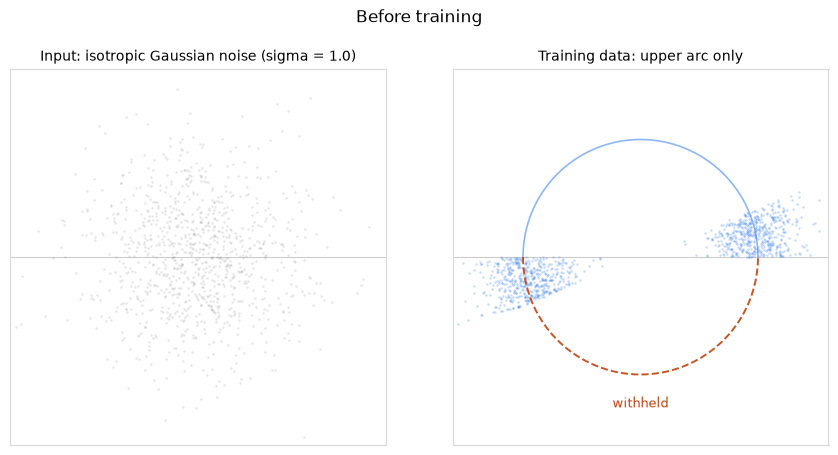

In [32]:
RADIUS = 1.0        # circle radius
WIDTH = 0.2        # radial jitter of the data
NOISE_SCALE = 1.0   # standard deviation of the isotropic Gaussian noise

def sample_arc(count, angle_low, angle_high, radius=RADIUS, width=WIDTH):
    """Points on an arc of `radius`, angles uniform on [angle_low, angle_high]."""
    angle = angle_low + (angle_high - angle_low) * torch.rand(count, device=device)
    r = radius + width * torch.randn(count, device=device)
    return r[:, None] * torch.stack((angle.cos(), angle.sin()), dim=1)


def sample_train(count):
    """The ONLY data the models ever see: the upper half of the circle."""
    return torch.cat([sample_arc(count // 2, 0.0, math.pi / 8),
                        sample_arc(count // 2, math.pi, math.pi + math.pi / 8)], dim=0)


def sample_full(count):
    """Full circle. Reference for plots and metrics; never fed to training."""
    return sample_arc(count, 0.0, 2 * math.pi)


def sample_noise(count, dim=2):
    """Isotropic Gaussian noise. O(n)-invariant in any dimension, which is all
    the symmetrization argument needs -- toy 4 calls this with dim=3."""
    return NOISE_SCALE * torch.randn(count, dim, device=device)

HELD_OUT = "#c1440e"   # the withheld part of the shape
SEEN = "#1f6feb"       # data the model is trained on
GENERATED = "#0f7b6c"


def circle_xy(angle_low, angle_high, radius=RADIUS, steps=200):
    angle = torch.linspace(angle_low, angle_high, steps)
    return radius * angle.cos(), radius * angle.sin()


def report_cropped(ax, limit):
    """Say so on the panel if the frame hid any points.

    Axis limits crop outliers silently, which would make a model look tidier
    than it is. Every scatter records what it drew so this can check.
    """
    drawn = getattr(ax, "_drawn_points", None)
    if drawn is None:
        return
    outside = int((drawn.abs().amax(dim=-1) > limit).sum())
    if outside:
        ax.text(0.99, 0.01, f"{outside} of {len(drawn)} points off-frame",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=7, color=HELD_OUT)


def style_axes(ax, limit=1.6, midline=True):
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal")
    if midline:
        ax.axhline(0.0, color="0.8", lw=0.8, zorder=0)
    ax.set_xticks([]), ax.set_yticks([])
    for side in ax.spines.values():
        side.set_color("0.85")
    report_cropped(ax, limit)


def draw_reference(ax):
    """Solid where data exists, dashed red where it was withheld."""
    ax.plot(*circle_xy(0, math.pi), color=SEEN, lw=1.2, alpha=0.5, zorder=1)
    ax.plot(*circle_xy(math.pi, 2 * math.pi), color=HELD_OUT, lw=1.4,
            ls="--", alpha=0.9, zorder=1)


def scatter(ax, points, color, title, size=3, alpha=0.25):
    """Draws EVERY point it is given. Never subsample here: thinning a scatter
    hides rare structure, such as toy 2's spurs and toy 3's stray mass."""
    p = points.detach().cpu()
    ax.scatter(p[:, 0], p[:, 1], s=size, c=color, alpha=alpha, linewidths=0)
    ax._drawn_points = p
    ax.set_title(title, fontsize=10)

figure, axes = plt.subplots(1, 2, figsize=(9, 4.6))

scatter(axes[0], sample_noise(1000), "0.45",
        f"Input: isotropic Gaussian noise (sigma = {NOISE_SCALE})", alpha=0.18)
style_axes(axes[0], limit=3.4)

scatter(axes[1], sample_train(1000), SEEN, "Training data: upper arc only")
draw_reference(axes[1])
axes[1].text(0.0, -1.28, "withheld", color=HELD_OUT, ha="center", fontsize=9)
style_axes(axes[1])

figure.tight_layout()
figure.subplots_adjust(top=0.85)
figure.suptitle("Before training", fontsize=12)
plt.show()


### Models

In [30]:
class O2Generator(nn.Module):
    """f(z) = rho(||z||) * z / ||z||  -- the general O(2)-equivariant map R^2 -> R^2.

    The scalar branch predicts the OUTPUT RADIUS directly rather than a scale
    factor. Much better conditioned: the target is rho ~ 1 instead of s ~ 1/r,
    which blows up near the origin.
    """

    def __init__(self, hidden=128, basis=16, max_radius=4.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0.0, max_radius, basis))
        self.gamma = 1.0 / (max_radius / max(basis - 1, 1)) ** 2
        self.net = nn.Sequential(
            nn.Linear(basis + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def radius_profile(self, r):
        """rho(r), the entire learned content of this model."""
        radial = torch.exp(-self.gamma * (r - self.centers).square())
        return nn.functional.softplus(self.net(torch.cat((r, radial), dim=-1)))

    def forward(self, z):
        r = z.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        return self.radius_profile(r) * z / r


class PlainGenerator(nn.Module):
    """Unconstrained control. Same data, same loss, no symmetry."""

    def __init__(self, hidden=128, dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, z):
        return self.net(z)

In [33]:
TEMP = 0.4


def train(model, sample_target=sample_train, temp=TEMP, temp_end=None, steps=4000,
        batch=512, lr=2e-3, cosine=False, dim=2, mode="gradient",
        report_every=1000):
    """One-step drift matching.

    `cosine` anneals the learning rate to zero. The drift target moves as the
    model moves, so at a constant rate the model orbits the optimum rather than
    settling; harmless for the circle, visible on the star's corners.

    `temp_end` geometrically anneals the kernel width from `temp` down to it.
    A narrow kernel gives a point far from the target almost no pull back, so
    starting wide fixes the global structure before sharpening. Toy 3 needs it.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    schedule = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
                if cosine else None)
    # A drift factory maps a kernel width to a drift function, so the loss
    # itself can be swapped out while annealing still works.
    history = []
    for step in range(steps + 1):
        width = temp if temp_end is None else temp * (temp_end / temp) ** (step / steps)
        generated = model(sample_noise(batch, dim))
        loss = drifting_loss(generated, sample_target(batch), partial(compute_V, temp=width, mode=mode))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if schedule is not None:
            schedule.step()
        history.append(float(loss.detach()))
        if step % report_every == 0:
            print(f"  step {step:6d}   loss {history[-1]:.3e}")
    return history


torch.manual_seed(7)
equivariant_unnormalized = O2Generator().to(device)
print("O2Generator")
equivariant_history = train(equivariant_unnormalized)

torch.manual_seed(7)
equivariant_normalized = O2Generator().to(device)
print("O2Generator (normalized)")
equivariant_normalized_history = train(equivariant_normalized, mode="base")

torch.manual_seed(7)
control = PlainGenerator().to(device)
print("PlainGenerator (control)")
control_history = train(control)


with torch.no_grad():
    equivariant_samples = equivariant_unnormalized(sample_noise(20_000))
    equivariant_normalized_samples = equivariant_normalized(sample_noise(20_000))
    control_samples = control(sample_noise(20_000))

O2Generator
  step      0   loss 1.493e+04
  step   1000   loss 7.154e+03
  step   2000   loss 6.949e+03
  step   3000   loss 7.304e+03
  step   4000   loss 6.919e+03
O2Generator (normalized)
  step      0   loss 2.389e+03
  step   1000   loss 1.145e+03
  step   2000   loss 1.112e+03
  step   3000   loss 1.169e+03
  step   4000   loss 1.107e+03
PlainGenerator (control)
  step      0   loss 9.974e+04
  step   1000   loss 1.120e+03
  step   2000   loss 3.968e+02
  step   3000   loss 4.133e+02
  step   4000   loss 8.278e+02


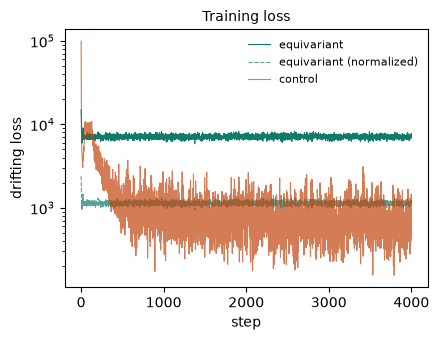

In [34]:
plt.figure(figsize=(4.5, 3.5))
plt.plot(equivariant_history, color=GENERATED, lw=0.8, label="equivariant")
plt.plot(equivariant_normalized_history, color=GENERATED, lw=0.8, ls="--", alpha=0.7, label="equivariant (normalized)")
plt.plot(control_history, color=HELD_OUT, lw=0.8, alpha=0.7, label="control")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("drifting loss")
plt.title("Training loss", fontsize=10)
plt.legend(fontsize=8, frameon=False)
plt.tight_layout()

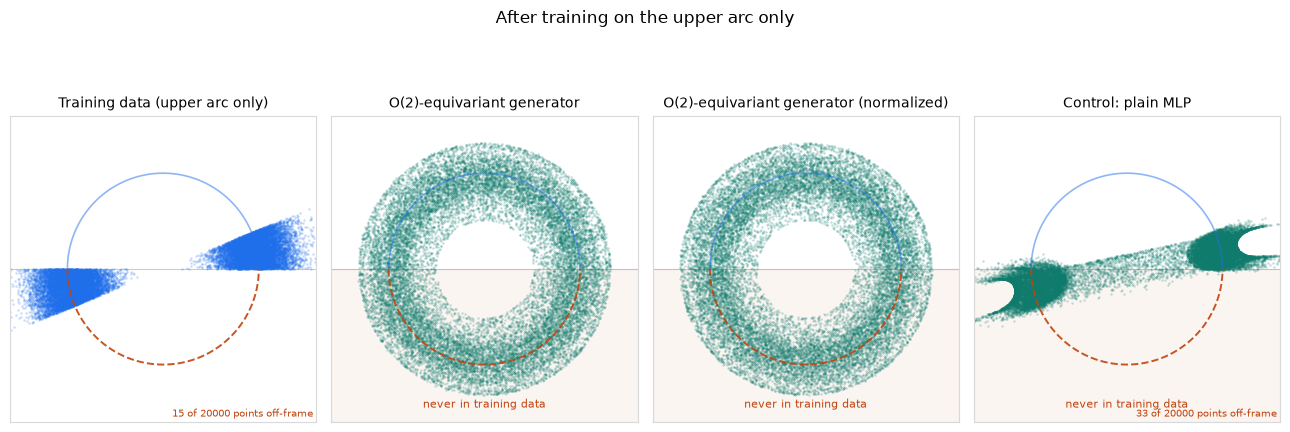

In [35]:

figure, axes = plt.subplots(1, 4, figsize=(13, 4.8))

scatter(axes[0], sample_train(20_000), SEEN, "Training data (upper arc only)")
draw_reference(axes[0])
style_axes(axes[0])

scatter(axes[1], equivariant_samples, GENERATED,
        "O(2)-equivariant generator")
draw_reference(axes[1])
style_axes(axes[1])

scatter(axes[2], equivariant_normalized_samples, GENERATED,
        "O(2)-equivariant generator (normalized)")
draw_reference(axes[2])
style_axes(axes[2])

scatter(axes[3], control_samples, GENERATED, "Control: plain MLP")
draw_reference(axes[3])
style_axes(axes[3])

for ax in axes[1:]:
    ax.axhspan(-1.6, 0.0, color=HELD_OUT, alpha=0.05, zorder=0)
    ax.text(0.0, -1.45, "never in training data", color=HELD_OUT,
            ha="center", fontsize=8)

figure.tight_layout()
figure.subplots_adjust(top=0.85)
figure.suptitle("After training on the upper arc only", fontsize=12)
plt.show()
